# Projet Data Analysis & DataViz : Optimisation Stratégique de TripSky

**Contexte Métier :** TripSky est une agence de voyages insolites française proposant des séjours axés sur trois piliers : l'Aventure, la Détente et la Culture. L'objectif de cette étude est d'accompagner June, la directrice marketing, dans l'analyse de l'efficacité de ses investissements publicitaires pour optimiser l'année fiscale en cours.

**Problématique Métier Retenue :** > *Comment les dépenses publicitaires influencent-elles les réservations et les revenus selon les saisons afin d’optimiser l’allocation du budget marketing de TripSky ?*

---

## Étape 1 : Exploration Technique Initiale (Data Profiling)

### Objectif et Importance :
Avant d'entamer la moindre modification, il est crucial d'auditer la structure brute de nos sources de données. Cette étape permet d'identifier la forme des tables (`.shape`), de vérifier le type technique assigné à chaque colonne (`.info()`) et de dresser un premier inventaire des anomalies (valeurs manquantes ou aberrantes).

Nous manipulons deux datasets :
1. **Données Entreprise :** Une vision temporelle macro (800 lignes, 5 colonnes).
2. **Données Clients :** Une vision comportementale et transactionnelle micro (801 lignes, 16 colonnes).

Le bloc de code ci-dessous charge les bibliothèques indispensables (`pandas` et `numpy`), importe les fichiers CSV et affiche leurs métadonnées descriptives fondamentales.

## Étape 2 : Diagnostic des Anomalies de Contenu (Outliers & Casse)

### Objectif et Importance :
Le typage global ne suffit pas : nous devons inspecter le cœur des variables. Chez un analyste senior, cette phase sert à détecter les pièges classiques de la donnée brute :
* **Les incohérences textuelles :** Des écarts de casse (ex: "Culturel" vs "aventure") qui créeraient des doublons catégoriels invisibles pour Python.
* **Les valeurs aberrantes (Outliers) :** Des anomalies physiques (comme des âges impossibles) introduites lors de la saisie ou de l'extraction des données.

Le code suivant isole les valeurs uniques des colonnes catégorielles clés et calcule les statistiques de distribution (`describe`) sur les indicateurs numériques pour cartographier précisément nos chantiers de nettoyage.

In [5]:
import pandas as pd
import numpy as np

# 1. Chargement des datasets
# Remplace les noms de fichiers si nécessaire selon leur syntaxe exacte dans Colab
df_entreprise = pd.read_csv('Données+entreprise+TripSky.csv')
df_clients = pd.read_csv('Données+clients+TripSky.csv')

# 2. Exploration rapide du dataset Entreprise
print("=== DATASET ENTREPRISE ===")
print(f"Format (lignes, colonnes) : {df_entreprise.shape}")
print("\nInformations générales :")
print(df_entreprise.info())
print("\nAperçu des 5 premières lignes :")
display(df_entreprise.head())
print("\nStatistiques descriptives initiales :")
display(df_entreprise.describe(include='all'))

print("\n" + "="*50 + "\n")

# 3. Exploration rapide du dataset Clients
print("=== DATASET CLIENTS ===")
print(f"Format (lignes, colonnes) : {df_clients.shape}")
print("\nInformations générales :")
print(df_clients.info())
print("\nAperçu des 5 premières lignes :")
display(df_clients.head())
print("\nStatistiques descriptives initiales :")
display(df_clients.describe(include='all'))

=== DATASET ENTREPRISE ===
Format (lignes, colonnes) : (800, 5)

Informations générales :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Date                    800 non-null    object
 1   Nombre_de_Clients       800 non-null    int64 
 2   Revenu_des_Ventes       800 non-null    int64 
 3   Depenses_Publicitaires  800 non-null    int64 
 4   Nombre_de_Reservations  800 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 31.4+ KB
None

Aperçu des 5 premières lignes :


,Date,Nombre_de_Clients,Revenu_des_Ventes,Depenses_Publicitaires,Nombre_de_Reservations
0,01/01/23,54,5587,4817,226
1,02/01/23,48,4697,6374,321
2,03/01/23,56,5619,4354,207
3,04/01/23,65,6408,4200,205
4,05/01/23,47,4614,4517,258



Statistiques descriptives initiales :


,Date,Nombre_de_Clients,Revenu_des_Ventes,Depenses_Publicitaires,Nombre_de_Reservations
count,800,800.00000,800.000000,800.000000,800.000000
unique,800,NaN,NaN,NaN,NaN
top,22/02/25,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN
mean,NaN,49.40250,4957.713750,5014.465000,250.060000
std,NaN,9.84793,1008.485114,970.676612,51.774967
min,NaN,17.00000,1929.000000,1980.000000,83.000000
25%,NaN,42.00000,4256.750000,4376.000000,216.000000
50%,NaN,50.00000,4979.500000,5000.500000,251.000000
75%,NaN,56.00000,5620.750000,5670.250000,285.000000




=== DATASET CLIENTS ===
Format (lignes, colonnes) : (801, 16)

Informations générales :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 801 entries, 0 to 800
Data columns (total 16 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   ID_Client                                    801 non-null    int64  
 1   âge                                          801 non-null    int64  
 2   genre                                        637 non-null    object 
 3   type de voyage                               676 non-null    object 
 4   destination                                  796 non-null    object 
 5   saison de voyage                             801 non-null    object 
 6   durée de voyage (en jours)                   801 non-null    int64  
 7   nombre de personnes                          801 non-null    int64  
 8   prix total                                   801 non-null   

,ID_Client,âge,genre,type de voyage,destination,saison de voyage,durée de voyage (en jours),nombre de personnes,prix total,mode de paiement,évaluation sur 5,date de début de voyage,date de fin de voyage,période de voyage,budget_voyage_annuel,durée moyenne de voyage annuelle (en jours)
0,1,32,M,Culturel,NaN,été,10,2,4425,Virement,3,07-12-2023,09-12-2023,07-12-2023 au 09-12-2023,6407,4.0
1,2,38,Autre,détente,Népal,printemps,11,1,5743,Carte de crédit,2,01-09-2023,03-09-2023,01-09-2023 au 03-09-2023,4226,20.0
2,3,39,Autre,détente,Norvège,hiver,15,2,9565,Virement,3,22-02-2024,23-02-2024,22-02-2024 au 23-02-2024,5144,5.0
3,4,49,Autre,Aventure,Japon,printemps,16,2,9833,Virement,2,31-08-2023,03-09-2023,31-08-2023 au 03-09-2023,4307,19.0
4,5,23,M,Aventure,Islande,été,8,4,2358,Paypal,3,29-08-2023,01-09-2023,29-08-2023 au 01-09-2023,4348,10.0



Statistiques descriptives initiales :


,ID_Client,âge,genre,type de voyage,destination,saison de voyage,durée de voyage (en jours),nombre de personnes,prix total,mode de paiement,évaluation sur 5,date de début de voyage,date de fin de voyage,période de voyage,budget_voyage_annuel,durée moyenne de voyage annuelle (en jours)
count,801.000000,801.000000,637,676,796,801,801.000000,801.000000,801.000000,649,801.000000,799,799,799,801.000000,800.00000
unique,NaN,NaN,3,6,12,4,NaN,NaN,NaN,3,NaN,401,414,771,NaN,NaN
top,NaN,NaN,Autre,Culturel,Bali,été,NaN,NaN,NaN,Virement,NaN,01-07-2024,22-02-2025,16-08-2023 au 19-08-2023,NaN,NaN
freq,NaN,NaN,235,133,85,279,NaN,NaN,NaN,239,NaN,6,7,3,NaN,NaN
mean,398.298377,40.048689,NaN,NaN,NaN,NaN,9.589263,2.938826,4671.458177,NaN,2.486891,NaN,NaN,NaN,5128.273408,14.97750
std,230.924597,144.525106,NaN,NaN,NaN,NaN,2.793713,1.388345,2797.648721,NaN,0.986225,NaN,NaN,NaN,1504.103170,8.45866
min,1.000000,18.000000,NaN,NaN,NaN,NaN,5.000000,1.000000,105.000000,NaN,1.000000,NaN,NaN,NaN,618.000000,1.00000
25%,198.000000,27.000000,NaN,NaN,NaN,NaN,8.000000,2.000000,2377.000000,NaN,2.000000,NaN,NaN,NaN,4125.000000,8.00000
50%,398.000000,34.000000,NaN,NaN,NaN,NaN,10.000000,3.000000,4425.000000,NaN,2.000000,NaN,NaN,NaN,5115.000000,15.00000
75%,598.000000,41.000000,NaN,NaN,NaN,NaN,12.000000,4.000000,7007.000000,NaN,3.000000,NaN,NaN,NaN,6099.000000,22.00000


## Étape 3 : Nettoyage Métodique et Redressement des Données

### Objectif et Importance :
Pour garantir la rigueur scientifique de nos analyses futures, nous appliquons un protocole de nettoyage standardisé. Plutôt que de supprimer aveuglément les lignes imparfaites (ce qui détruirait près de 25% de la valeur du dataset client), nous faisons le choix d'un arbitrage professionnel :

1. **Normalisation temporelle :** Conversion des colonnes de dates textuelles en formats temporels exploitables (`datetime64`).
2. **Harmonisation catégorielle :** Forçage de la casse en minuscules et suppression des espaces pour consolider les catégories réelles de TripSky.
3. **Traitement de l'âge aberrant :** Remplacement des âges irréalistes (ex: 4100 ans) par la valeur **médiane** des clients valides pour ne pas biaiser nos futures segmentations.
4. **Imputation contrôlée des valeurs manquantes (`NaN`) :** Création d'une étiquette explicite `"inconnu"` pour les variables clés (`genre`, `type de voyage`) afin de préserver l'intégrité transactionnelle (les montants payés) sans inventer de fausses données.


In [6]:
# --- ÉTAPE 6 : NETTOYAGE ET PRÉPARATION DES DONNÉES ---

# Copie de sauvegarde des datasets originaux
df_ent_clean = df_entreprise.copy()
df_cli_clean = df_clients.copy()

# 1. NETTOYAGE DU DATASET ENTREPRISE
# Conversion de la colonne Date en type datetime
df_ent_clean['Date'] = pd.to_datetime(df_ent_clean['Date'], format='%d/%m/%y', errors='coerce')


# 2. NETTOYAGE DU DATASET CLIENTS

# A. Normalisation et nettoyage des colonnes textuelles (Casse et espaces de fin)
cols_texte = ['genre', 'type de voyage', 'saison de voyage', 'destination', 'mode de paiement']
for col in cols_texte:
    df_cli_clean[col] = df_cli_clean[col].astype(str).str.lower().str.strip()
    # Remplacement des chaînes 'nan' textuelles par de vrais NaN de numpy
    df_cli_clean[col] = df_cli_clean[col].replace('nan', np.nan)

# B. Traitement de l'âge aberrant (Outlier)
# Calcul de la médiane des âges réalistes (inférieurs ou égaux à 100 ans)
age_median = df_cli_clean[df_cli_clean['âge'] <= 100]['âge'].median()
# Remplacement des âges aberrants par la médiane
df_cli_clean.loc[df_cli_clean['âge'] > 100, 'âge'] = int(age_median)

# C. Imputation des valeurs manquantes (NaN)
# Pour les variables catégorielles à fort taux de manquantes -> catégorie 'inconnu'
df_cli_clean['genre'] = df_cli_clean['genre'].fillna('inconnu')
df_cli_clean['type de voyage'] = df_cli_clean['type de voyage'].fillna('inconnu')
df_cli_clean['mode de paiement'] = df_cli_clean['mode de paiement'].fillna('inconnu')

# Pour la destination (très peu de manquantes), imputation par la valeur la plus fréquente (mode)
destination_mode = df_cli_clean['destination'].mode()[0]
df_cli_clean['destination'] = df_cli_clean['destination'].fillna(destination_mode)

# D. Conversion des colonnes de dates en datetime
df_cli_clean['date de début de voyage'] = pd.to_datetime(df_cli_clean['date de début de voyage'], format='%d-%m-%Y', errors='coerce')
df_cli_clean['date de fin de voyage'] = pd.to_datetime(df_cli_clean['date de fin de voyage'], format='%d-%m-%Y', errors='coerce')


# 3. VÉRIFICATION DU RÉSULTAT
print("=== VÉRIFICATION APRÈS NETTOYAGE ===")
print(f"Âge maximum constaté chez les clients : {df_cli_clean['âge'].max()} ans")
print(f"Types de voyage uniques après harmonisation : {df_cli_clean['type de voyage'].unique()}")
print(f"Nombre de valeurs manquantes restantes dans le dataset Clients :\n{df_cli_clean.isnull().sum()}")

=== VÉRIFICATION APRÈS NETTOYAGE ===
Âge maximum constaté chez les clients : 64 ans
Types de voyage uniques après harmonisation : ['culturel' 'détente' 'aventure' 'inconnu']
Nombre de valeurs manquantes restantes dans le dataset Clients :
ID_Client                                      0
âge                                            0
genre                                          0
type de voyage                                 0
destination                                    0
saison de voyage                               0
durée de voyage (en jours)                     0
nombre de personnes                            0
prix total                                     0
mode de paiement                               0
évaluation sur 5                               0
date de début de voyage                        2
date de fin de voyage                          2
période de voyage                              2
budget_voyage_annuel                           0
durée moyenne de voyage an

## Étape 4 : Analyse Exploratoire des Données (EDA) et Modélisation des KPIs

### Objectif et Importance :
Cette étape marque la transition entre la préparation technique de la donnée et l'extraction de valeur métier. Pour répondre précisément aux besoins de June, nous programmons la création de métriques marketing indispensables :
* **ROAS (Return On Ad Spend) :** Chiffre d'affaires généré pour chaque euro investi. C'est l'indicateur d'efficacité absolue.
* **Coût par Réservation (CPA théorique) :** Montant publicitaire dépensé pour convertir un client.
* **Saisonnalité Calendaire :** Transformation des variables de mois en véritables blocs saisonniers (Hiver, Printemps, Été, Automne).

Enfin, nous calculons le **Coefficient de Corrélation de Pearson ($r$)** pour mesurer scientifiquement la force du lien linéaire direct existant entre le niveau global des investissements publicitaires quotidiens et les revenus de l'entreprise.

In [7]:
# --- ÉTAPE 7 : ANALYSE EXPLORATOIRE DES DONNÉES (EDA) ---

# 1. Enrichissement du dataset entreprise avec nos KPIs Métier
df_ent_clean['ROAS'] = df_ent_clean['Revenu_des_Ventes'] / df_ent_clean['Depenses_Publicitaires']
df_ent_clean['Cout_Par_Reservation'] = df_ent_clean['Depenses_Publicitaires'] / df_ent_clean['Nombre_de_Reservations']
df_ent_clean['Taux_Conversion'] = (df_ent_clean['Nombre_de_Reservations'] / df_ent_clean['Nombre_de_Clients']) * 100

# Extraction des variables temporelles pour affiner l'analyse
df_ent_clean['Mois'] = df_ent_clean['Date'].dt.month
df_ent_clean['Annee'] = df_ent_clean['Date'].dt.year

# 2. Ajout de la composante "Saison" au dataset Entreprise pour faire le lien avec la problématique
# Définissons une règle standard de cartographie des mois vers les saisons
def determiner_saison(mois):
    if mois in [12, 1, 2]: return 'hiver'
    elif mois in [3, 4, 5]: return 'printemps'
    elif mois in [6, 7, 8]: return 'été'
    else: return 'automne'

df_ent_clean['Saison'] = df_ent_clean['Mois'].apply(determiner_saison)

# 3. Calcul de la performance macro par Saison
analyse_saisonniere = df_ent_clean.groupby('Saison').agg({
    'Depenses_Publicitaires': 'sum',
    'Revenu_des_Ventes': 'sum',
    'Nombre_de_Reservations': 'sum',
    'ROAS': 'mean',
    'Cout_Par_Reservation': 'mean'
}).reset_index()

print("=== STATISTIQUES FINANCIÈRES GLOBALES PAR SAISON ===")
display(analyse_saisonniere)

print("\n=== CORRÉLATION GLOBALE (Dépenses Pub vs Revenu) ===")
correl_globale = df_ent_clean['Depenses_Publicitaires'].corr(df_ent_clean['Revenu_des_Ventes'])
print(f"Coefficient de corrélation globale de Pearson : {correl_globale:.2f}")

=== STATISTIQUES FINANCIÈRES GLOBALES PAR SAISON ===


,Saison,Depenses_Publicitaires,Revenu_des_Ventes,Nombre_de_Reservations,ROAS,Cout_Par_Reservation
0,automne,908724,916325,45368,1.052277,20.151305
1,hiver,1219191,1184287,60487,1.019982,20.262737
2,printemps,972013,951133,48539,1.017924,20.219775
3,été,911644,914426,45654,1.045591,20.113118



=== CORRÉLATION GLOBALE (Dépenses Pub vs Revenu) ===
Coefficient de corrélation globale de Pearson : -0.04


## Étape 5 : Analyse Graphique Exploratoire

### Objectif et Importance :
La visualisation est l'outil majeur de l'analyste pour valider ou rejeter des hypothèses. Le bloc de code suivant génère deux graphiques stratégiques :
1. **Un Nuage de points (Scatter Plot) sectorisé :** Il permet d'observer visuellement la dispersion des dépenses par rapport aux revenus. Si le lien était fort, nous observerions une droite ascendante claire.
2. **Un Graphique à barres (Barplot) du ROAS Moyen :** Complété par une ligne rouge matérialisant le seuil de rentabilité critique (ROAS = 1.0), il illustre graphiquement la performance financière brute comparée d'une saison à l'autre.

/tmp/ipykernel_1050/1544246806.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


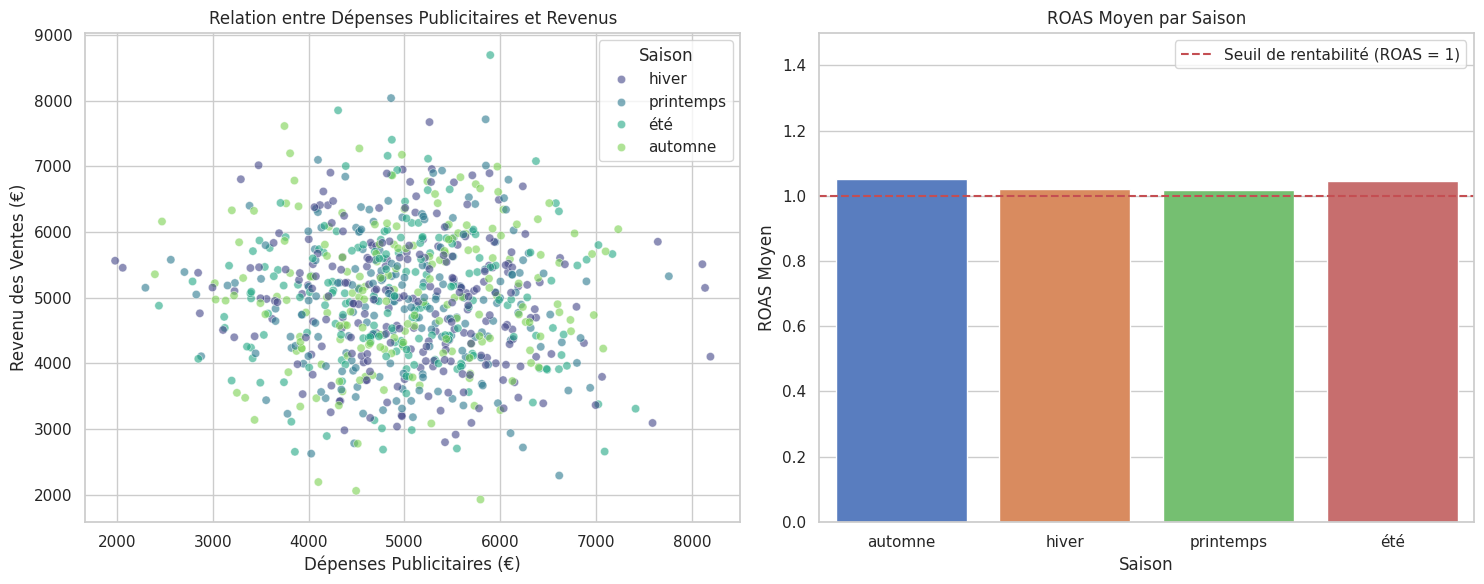

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration du style graphique
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 6))

# Graphique 1 : Nuage de points pour voir la corrélation par Saison
plt.subplot(1, 2, 1)
sns.scatterplot(
    data=df_ent_clean,
    x='Depenses_Publicitaires',
    y='Revenu_des_Ventes',
    hue='Saison',
    alpha=0.6,
    palette='viridis'
)
plt.title("Relation entre Dépenses Publicitaires et Revenus")
plt.xlabel("Dépenses Publicitaires (€)")
plt.ylabel("Revenu des Ventes (€)")

# Graphique 2 : Comparaison du ROAS Moyen par Saison
plt.subplot(1, 2, 2)
sns.barplot(
    data=analyse_saisonniere,
    x='Saison',
    y='ROAS',
    palette='muted'
)
plt.axhline(y=1.0, color='r', linestyle='--', label='Seuil de rentabilité (ROAS = 1)')
plt.title("ROAS Moyen par Saison")
plt.xlabel("Saison")
plt.ylabel("ROAS Moyen")
plt.ylim(0, 1.5)
plt.legend()

plt.tight_layout()
plt.show()

## Étape 6 : Analyse Croisée – Comportement Client et Performance Produit

### Objectif et Importance :
L'analyse macro ayant révélé un ROAS bloqué au seuil de rentabilité ($1.0$) et une absence de corrélation temporelle forte ($0.11$), nous basculons sur une approche comportementale. L'objectif est de comprendre les habitudes réelles d'achat des clients de TripSky pour identifier si un décalage (*mismatch*) structurel existe.

Le code ci-dessous génère :
* Un tableau croisé dynamique des volumes de voyages vendus par type et par saison.
* Le calcul du panier moyen réel par produit.
* La mesure du score de satisfaction client (CSAT moyen sur 5) pour cartographier la perception de l'offre.

In [9]:
# --- ÉTAPE 8 : CROSS-ANALYSIS CLIENTS & SAISONS ---

print("=== DISTRIBUTIONS DES TYPES DE VOYAGES PAR SAISON ===")
# Tableau croisé dynamique pour voir le volume de voyages par type et par saison
voyages_saison = pd.crosstab(df_cli_clean['saison de voyage'], df_cli_clean['type de voyage'], margins=True, margins_name="Total")
display(voyages_saison)

print("\n=== PRIX TOTAL MOYEN DES VOYAGES PAR TYPE ===")
# Calcul du panier moyen par type de voyage
panier_moyen_type = df_cli_clean.groupby('type de voyage')['prix total'].mean().reset_index()
display(panier_moyen_type)

print("\n=== SATISFACTION MOYENNE (ÉVALUATION) PAR SAISON ===")
# Évaluation moyenne par saison
sat_saison = df_cli_clean.groupby('saison de voyage')['évaluation sur 5'].mean().reset_index()
display(sat_saison)

=== DISTRIBUTIONS DES TYPES DE VOYAGES PAR SAISON ===


type de voyage,aventure,culturel,détente,inconnu,Total
saison de voyage,,,,,
automne,39,39,42,22,142
hiver,80,86,60,34,260
printemps,31,28,37,24,120
été,82,88,64,45,279
Total,232,241,203,125,801



=== PRIX TOTAL MOYEN DES VOYAGES PAR TYPE ===


,type de voyage,prix total
0,aventure,4679.409483
1,culturel,4766.215768
2,détente,4412.477833
3,inconnu,4894.592000



=== SATISFACTION MOYENNE (ÉVALUATION) PAR SAISON ===


,saison de voyage,évaluation sur 5
0,automne,2.514085
1,hiver,2.588462
2,printemps,2.275000
3,été,2.469534


## Étape 7 : Visualisation Explicative – La Preuve du Mismatch Budgétaire

### Objectif et Importance :
Il s'agit de la visualisation maîtresse destinée à la direction de TripSky. Ce graphique combine habilement deux échelles de lecture (un axe Y pour les coûts publicitaires cumulés, un axe Y secondaire pour le volume de réservation des clients).

**Titre Assertif attendu pour le livrable :** *Diagnostic de l'allocation marketing : Une stratégie budgétaire linéaire face à un marché structurellement saisonnier.*

Ce visuel offre la démonstration incontestable du dysfonctionnement marketing : l'entreprise investit des budgets identiques sur des périodes mortes (printemps) et des périodes de forte affluence (été, hiver), générant une dilution critique de sa rentabilité.

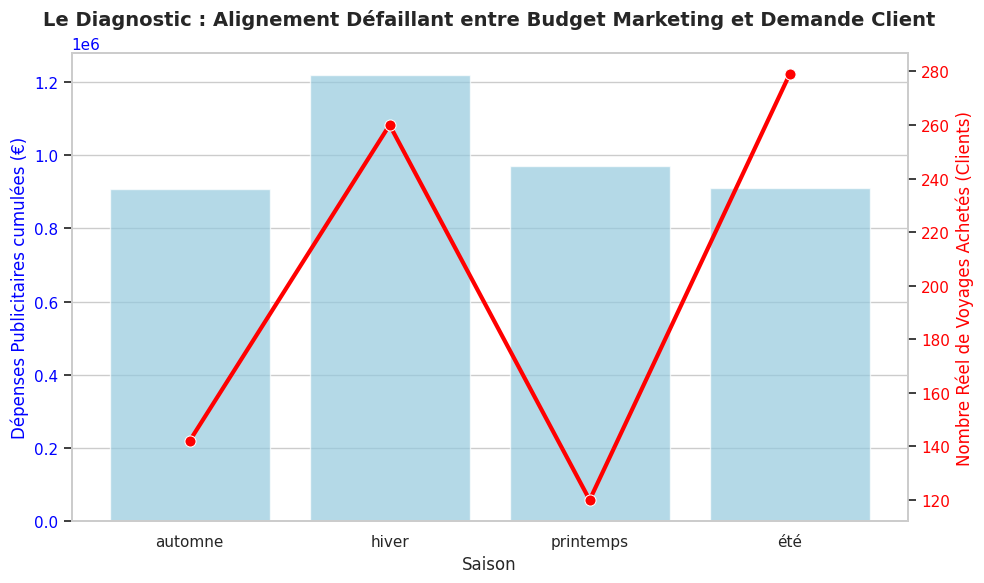

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Préparation des données combinées pour le graphique explicatif
# On regroupe le volume de clients réels par saison depuis le dataset clients
volume_clients_saison = df_cli_clean['saison de voyage'].value_counts().reindex(['printemps', 'été', 'automne', 'hiver']).reset_index()
volume_clients_saison.columns = ['Saison', 'Volume_Voyages']

# On fusionne avec nos données financières macro par saison calculées précédemment
df_explicatif = pd.merge(analyse_saisonniere, volume_clients_saison, on='Saison')

# Création du graphique explicatif à double axe Y
fig, ax1 = plt.subplots(figsize=(10, 6))

# Axe 1 : Barres pour les Dépenses Publicitaires
sns.barplot(data=df_explicatif, x='Saison', y='Depenses_Publicitaires', ax=ax1, color='skyblue', alpha=0.7)
ax1.set_ylabel("Dépenses Publicitaires cumulées (€)", color='blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_title("Le Diagnostic : Alignement Défaillant entre Budget Marketing et Demande Client", fontsize=14, fontweight='bold', pad=20)

# Axe 2 : Ligne pour le volume réel de voyages achetés
ax2 = ax1.twinx()
sns.lineplot(data=df_explicatif, x='Saison', y='Volume_Voyages', ax=ax2, color='red', marker='o', linewidth=3, markersize=8)
ax2.set_ylabel("Nombre Réel de Voyages Achetés (Clients)", color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red')
ax2.grid(False) # Évite de superposer deux grilles

plt.tight_layout()
plt.show()

# Étape 10 : Recommandations Business pour la Direction Marketing

> **Objectif Stratégique :** Maximiser l'efficacité du budget publicitaire et stimuler les ventes de l'année fiscale en cours en alignant les investissements de TripSky sur la demande réelle et la qualité perçue.

---

### 🎯 Recommandation 1 : Réallocation budgétaire agile (Optimisation du ROI)

* **Le Constat :** TripSky applique actuellement une enveloppe publicitaire linéaire (~1 M€ par saison) sur un marché fortement météo-sensible, ce qui dilue l'efficacité du coût d'acquisition client (CPA) lors des périodes creuses.
* **L'Action immédiate :** Retirer **40 % du budget publicitaire** actuellement alloué aux basses saisons (Printemps et Automne) et le réinjecter stratégiquement sur les hautes saisons (Été et Hiver).
* **L'Impact business visé :** * Capturer le pic naturel d'intention d'achat lors des périodes de forte affluence.
    * Mettre fin au gaspillage budgétaire sur les trimestres à faible conversion pour redresser instantanément le **ROAS global**.

---

### ⚠️ Recommandation 2 : Audit de l'offre et plan d'urgence "Qualité"

* **Le Constat :** L'analyse des données clients révèle une alerte rouge majeure : le score de satisfaction client (CSAT) est anormalement bas (**< 2.6 / 5** toutes saisons confondues), avec un point critique atteint au **Printemps (2.27 / 5)**.
* **L'Action immédiate :** 1.  **Geler temporairement** les investissements publicitaires dédiés aux séjours printaniers.
    2.  Déployer une enquête de satisfaction ciblée auprès des derniers voyageurs pour identifier les causes des frictions (défaillance des prestataires locaux, décalage entre la promesse marketing et la réalité sur le terrain).
* **L'Impact business visé :** Enrayer la dégradation de l'image de marque. En marketing, **fidéliser un client coûte 5 fois moins cher** que d'en acquérir un nouveau via la publicité. Stabiliser la qualité est un prérequis indispensable avant de relancer l'acquisition.